<a href="https://colab.research.google.com/github/Newbluewood/ML-SentimentModelForReviews/blob/main/notebooks/product_category_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📥 Učitavanje i pregled skupa podataka

Pre analize učitavamo skup i gledamo strukturu — bez ikakvih izmena.

U ovom koraku:
- učitavamo CSV sa GitHub-a
- proveravamo broj redova i kolona
- prikazujemo prvih nekoliko redova

**Cilj projekta:** na osnovu **Product Title** predvideti **Category Label**.


In [1]:
import pandas as pd

url = (
    "https://raw.githubusercontent.com/Newbluewood/"
    "ML-SentimentModelForReviews/main/data/IMLP4_TASK_03-products.csv"
)
df = pd.read_csv(url)
df.columns = df.columns.str.strip()


In [2]:
print("Oblik skupa (redovi, kolone):", df.shape)
display(df.head())


Oblik skupa (redovi, kolone): (35311, 8)


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


**Zaključak:** Skup je učitan. Sledeći korak — tipovi kolona i broj popunjenih vrednosti.


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  object 
 2   Merchant ID      35311 non-null  int64  
 3   Category Label   35267 non-null  object 
 4   _Product Code    35216 non-null  object 
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7   Listing Date     35252 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.2+ MB


## 🔍 Provera nedostajućih vrednosti

Nedostajući podaci kvare treniranje. Ovde samo **dijagnostikujemo** — još ne brišemo.


In [4]:
print("Nedostajuće vrednosti po kolonama:")
print(df.isna().sum())


Nedostajuće vrednosti po kolonama:
product ID           0
Product Title      172
Merchant ID          0
Category Label      44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
Listing Date        59
dtype: int64


**Šta gledamo:** koje kolone imaju praznine i koliko ih ima.

Posebno su nam bitni **Product Title** i **Category Label** — bez njih red ne može u model.


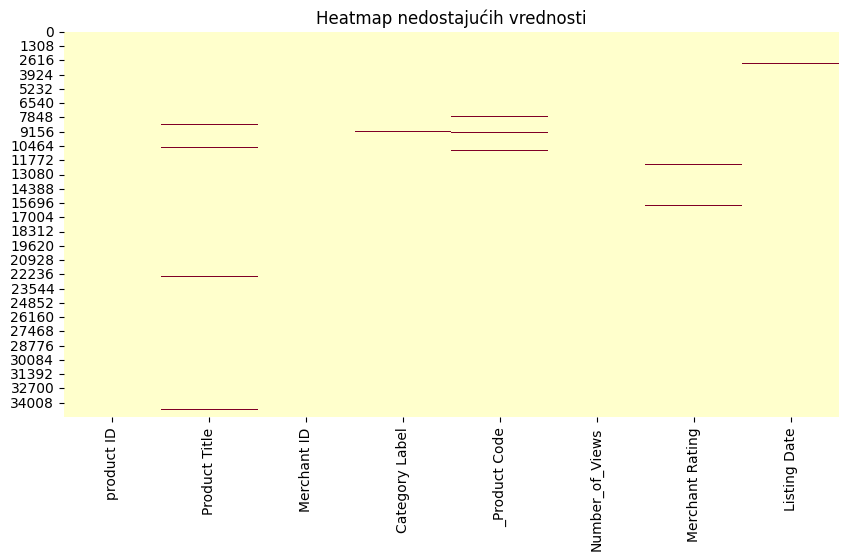

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap="YlOrRd")
plt.title("Heatmap nedostajućih vrednosti")
plt.show()


**Zaključak:** Vizuelno vidimo gde su rupe. Pre čišćenja pregledamo raspodelu kategorija i ključne kolone.


## 📊 Analiza raspodele kategorija

Pregledamo ciljnu promenljivu na **sirovom** skupu — kao sentiment analiza u ITA-ML.


In [6]:
raspodela_kategorija = df["Category Label"].value_counts()
print("Broj različitih kategorija:", df["Category Label"].nunique())
print(raspodela_kategorija)


Broj različitih kategorija: 13
Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


**Šta tražimo:**
- da li su klase neuravnotežene
- da li postoje dupli nazivi iste kategorije (npr. `fridge` i `Fridges`)

Ako vidimo nekonzistentnosti, ispravićemo ih posle `dropna()`.


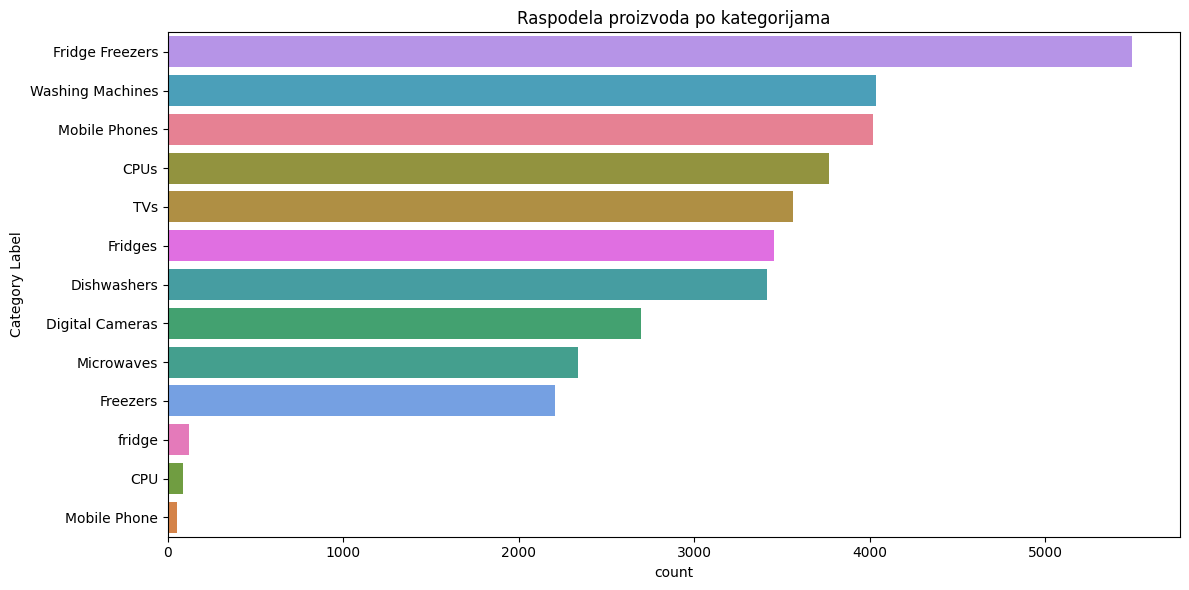

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df, y="Category Label",
    order=raspodela_kategorija.index,
    hue="Category Label", legend=False
)
plt.title("Raspodela proizvoda po kategorijama")
plt.tight_layout()
plt.show()


## 📝 Istraživanje kolone `Product Title`

Glavni ulaz modela. Pre čišćenja proveravamo kako je kolona zapisana.


In [8]:
print("Tip kolone:", df["Product Title"].dtype)
print("\nPrvih 10 naslova:")
print(df["Product Title"].head(10).to_string(index=False))


Tip kolone: object

Prvih 10 naslova:
                   apple iphone 8 plus 64gb silver
               apple iphone 8 plus 64 gb spacegrau
apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim ...
               apple iphone 8 plus 64gb space grey
apple iphone 8 plus gold 5.5 64gb 4g unlocked s...
apple iphone 8 plus gold 5.5 64gb 4g unlocked s...
              apple iphone 8 plus 64 gb space grey
               apple iphone 8 plus 64gb space grey
               apple iphone 8 plus 64gb space grey
               apple iphone 8 plus 64gb space grey


In [9]:
duzina_raw = df["Product Title"].astype(str).str.len()
print("Statistika dužine naslova (znakovi):")
print(duzina_raw.describe())
print("\nRedova bez naslova:", df["Product Title"].isna().sum())


Statistika dužine naslova (znakovi):
count    35311.000000
mean        52.738240
std         22.652481
min          3.000000
25%         38.000000
50%         52.000000
75%         65.000000
max        200.000000
Name: Product Title, dtype: float64

Redova bez naslova: 172


**Zaključak:** Naslovi su tekst. Dužina varira po proizvodu — kasnije ćemo od toga napraviti karakteristiku.


## 💸 Istraživanje numeričkih kolona

Pregledamo `Merchant Rating` i `Number_of_Views` pre čišćenja — da znamo tipove i opseg vrednosti.


In [10]:
print("Merchant Rating")
print("  tip:", df["Merchant Rating"].dtype)
print(df["Merchant Rating"].describe())
print("\nNumber_of_Views")
print("  tip:", df["Number_of_Views"].dtype)
print(df["Number_of_Views"].describe())


Merchant Rating
  tip: float64
count    35141.000000
mean         2.998261
std          1.152664
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Merchant Rating, dtype: float64

Number_of_Views
  tip: float64
count    35297.000000
mean      2501.469587
std       1438.217697
min          0.000000
25%       1256.000000
50%       2509.000000
75%       3735.000000
max       5000.000000
Name: Number_of_Views, dtype: float64


**Zaključak:** Obe kolone su numeričke. Zadržavamo ih do `dropna()`; detaljnu analizu korelacije sa kategorijom (kvartili + boxplot) radimo posle standardizacije kategorija.


## 🧹 Uklanjanje nedostajućih vrednosti

Sada uklanjamo **sve redove** gde bilo koja kolona ima `NaN` — isto kao `df.dropna()` u ITA-ML.

**Zašto?** Dobijamo potpuno popunjen skup bez imputacije.


In [11]:
prethodni_broj = len(df)
df = df.dropna()
print("Pre:", prethodni_broj, "redova")
print("Posle:", df.shape[0], "redova")
print("Uklonjeno:", prethodni_broj - df.shape[0])


Pre: 35311 redova
Posle: 34760 redova
Uklonjeno: 551


In [12]:
print("Nedostajuće posle dropna:")
print(df.isna().sum())


Nedostajuće posle dropna:
product ID         0
Product Title      0
Merchant ID        0
Category Label     0
_Product Code      0
Number_of_Views    0
Merchant Rating    0
Listing Date       0
dtype: int64


**Zaključak:** Svaka ćelija ima vrednost. Sledeće — usklađivanje naziva kategorija.


## ✅ Standardizacija `Category Label`

Ispravljamo nekonzistentne nazive i postavljamo tip `category`.


In [13]:
print("PRE standardizacije:")
print(df["Category Label"].value_counts())


PRE standardizacije:
Category Label
Fridge Freezers     5424
Washing Machines    3971
Mobile Phones       3970
CPUs                3711
TVs                 3502
Fridges             3403
Dishwashers         3374
Digital Cameras     2661
Microwaves          2307
Freezers            2182
fridge               121
CPU                   81
Mobile Phone          53
Name: count, dtype: int64


In [14]:
ispravka_kategorija = {
    "fridge": "Fridges",
    "CPU": "CPUs",
    "Mobile Phone": "Mobile Phones",
}
df["Category Label"] = (
    df["Category Label"].astype(str).str.strip().replace(ispravka_kategorija)
)
df["Category Label"] = df["Category Label"].astype("category")
print("POSLE standardizacije:")
print(df["Category Label"].value_counts())


POSLE standardizacije:
Category Label
Fridge Freezers     5424
Mobile Phones       4023
Washing Machines    3971
CPUs                3792
Fridges             3524
TVs                 3502
Dishwashers         3374
Digital Cameras     2661
Microwaves          2307
Freezers            2182
Name: count, dtype: int64


**Zaključak:** Ostaje 10 čistih kategorija. Sledeće — čišćenje naslova.


## ✅ Uklanjanje razmaka u `Product Title`

Prvi korak čišćenja teksta — `strip()` sa početka i kraja.


In [15]:
print("PRE:")
print(df["Product Title"].head(3).to_string(index=False))
df["Product Title"] = df["Product Title"].astype(str).str.strip()
print("\nPOSLE:")
print(df["Product Title"].head(3).to_string(index=False))


PRE:
                   apple iphone 8 plus 64gb silver
               apple iphone 8 plus 64 gb spacegrau
apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim ...

POSLE:
                   apple iphone 8 plus 64gb silver
               apple iphone 8 plus 64 gb spacegrau
apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim ...


## ✂️ Uklanjanje suvišnih kolona

Ostavljamo samo `Product Title` i `Category Label` za model iz naslova.


In [16]:
df = df.drop(columns=[
    "product ID", "Merchant ID", "_Product Code",
    "Number_of_Views", "Merchant Rating", "Listing Date"
])
print("Kolone:", df.columns.tolist())
print("Oblik:", df.shape)


Kolone: ['Product Title', 'Category Label']
Oblik: (34760, 2)


**Zaključak:** Radni skup je spreman za feature engineering.


## 🧮 Kreiranje karakteristika iz naslova

Kao `review_length` u ITA-ML — brojčani signali iz teksta.

Prvo kreiramo karakteristike koje zavise od **velikih slova**, pa tek onda radimo lowercase.


In [17]:
df["broj_reci"] = df["Product Title"].str.split().str.len()
df["duzina_naslova"] = df["Product Title"].str.len()
print(df[["broj_reci", "duzina_naslova"]].describe())


          broj_reci  duzina_naslova
count  34760.000000    34760.000000
mean       8.663924       52.972066
std        4.160922       22.417916
min        1.000000        5.000000
25%        6.000000       39.000000
50%        8.000000       52.000000
75%       11.000000       65.000000
max       37.000000      200.000000


In [18]:
df["ima_brojeve"] = df["Product Title"].str.contains(r"\d", regex=True).astype(int)
df["ima_velika_slova"] = df["Product Title"].str.contains(r"[A-Z]", regex=True).astype(int)
df["max_duzina_reci"] = df["Product Title"].str.split().apply(
    lambda reci: max((len(r) for r in reci), default=0)
)
print("ima_brojeve — udeo sa ciframa:", df["ima_brojeve"].mean())
print("ima_velika_slova — udeo:", df["ima_velika_slova"].mean())


ima_brojeve — udeo sa ciframa: 0.9500287686996548
ima_velika_slova — udeo: 0.0


**Zaključak:** Karakteristike kreirane. Proveravamo da li se dužina naslova razlikuje po kategorijama.


In [19]:
print(df.groupby("Category Label", observed=False)["duzina_naslova"].mean().sort_values(ascending=False))


Category Label
CPUs                67.016350
Fridge Freezers     55.266777
TVs                 54.741576
Washing Machines    53.057416
Microwaves          51.788903
Dishwashers         50.184351
Digital Cameras     50.118001
Freezers            48.705775
Fridges             48.495743
Mobile Phones       46.155108
Name: duzina_naslova, dtype: float64


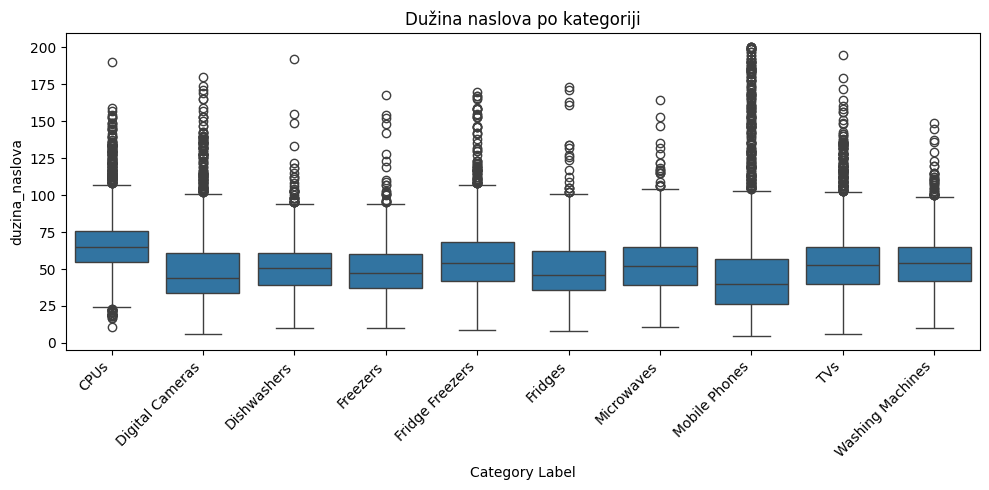

In [20]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Category Label", y="duzina_naslova")
plt.title("Dužina naslova po kategoriji")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## ✅ Pretvaranje naslova u mala slova

Posle FE — `lower()` za TF-IDF, da `iPhone` i `iphone` budu isti token.


In [21]:
df["Product Title"] = df["Product Title"].str.lower()
print(df["Product Title"].head(3).to_string(index=False))


                   apple iphone 8 plus 64gb silver
               apple iphone 8 plus 64 gb spacegrau
apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim ...


**Zaključak:** Podaci su očišćeni i pripremljeni. Sledeće — treniranje modela.


### 📚 Priprema za modeliranje

Definišemo ulaze (`X`), cilj (`y`) i delimo skup na trening i test.


In [22]:
from sklearn.model_selection import train_test_split

numeric_features = [
    "broj_reci", "duzina_naslova", "ima_brojeve",
    "ima_velika_slova", "max_duzina_reci"
]
X = df[["Product Title"] + numeric_features]
y = df["Category Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Trening:", X_train.shape, "| Test:", X_test.shape)


Trening: (27808, 6) | Test: (6952, 6)


**Zaključak:** 80% trening, 20% test, ista raspodela klasa (`stratify`). Sledeće — preprocessor i Pipeline.


In [23]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

preprocessor = ColumnTransformer(
    transformers=[
        ("title", TfidfVectorizer(), "Product Title"),
        ("numeric", MinMaxScaler(), numeric_features),
    ]
)
print("Preprocessor definisan.")


Preprocessor definisan.


### Treniranje modela — Logistic Regression


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

pipe_lr = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000)),
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
print("Tačnost:", round(accuracy_score(y_test, y_pred_lr), 4))
print(classification_report(y_test, y_pred_lr))


Tačnost: 0.9583
                  precision    recall  f1-score   support

            CPUs       1.00      0.99      1.00       758
 Digital Cameras       1.00      0.99      1.00       532
     Dishwashers       0.90      0.97      0.93       675
        Freezers       0.99      0.90      0.95       436
 Fridge Freezers       0.95      0.93      0.94      1085
         Fridges       0.90      0.91      0.91       705
      Microwaves       1.00      0.95      0.97       461
   Mobile Phones       0.98      0.99      0.98       805
             TVs       0.97      0.99      0.98       701
Washing Machines       0.94      0.95      0.94       794

        accuracy                           0.96      6952
       macro avg       0.96      0.96      0.96      6952
    weighted avg       0.96      0.96      0.96      6952



### Treniranje modela — Naive Bayes


In [25]:
from sklearn.naive_bayes import MultinomialNB

pipe_nb = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", MultinomialNB()),
])
pipe_nb.fit(X_train, y_train)
y_pred_nb = pipe_nb.predict(X_test)
print("Tačnost:", round(accuracy_score(y_test, y_pred_nb), 4))
print(classification_report(y_test, y_pred_nb))


Tačnost: 0.9184
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       758
 Digital Cameras       1.00      1.00      1.00       532
     Dishwashers       0.97      0.95      0.96       675
        Freezers       1.00      0.35      0.51       436
 Fridge Freezers       0.70      0.99      0.82      1085
         Fridges       0.91      0.78      0.84       705
      Microwaves       1.00      0.95      0.97       461
   Mobile Phones       0.99      0.99      0.99       805
             TVs       0.98      0.98      0.98       701
Washing Machines       0.99      0.96      0.97       794

        accuracy                           0.92      6952
       macro avg       0.95      0.89      0.90      6952
    weighted avg       0.94      0.92      0.91      6952



### Treniranje modela — Random Forest


In [26]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42)),
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
print("Tačnost:", round(accuracy_score(y_test, y_pred_rf), 4))
print(classification_report(y_test, y_pred_rf))


Tačnost: 0.9626
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       758
 Digital Cameras       1.00      0.99      0.99       532
     Dishwashers       0.95      0.97      0.96       675
        Freezers       0.94      0.93      0.93       436
 Fridge Freezers       0.94      0.94      0.94      1085
         Fridges       0.91      0.90      0.91       705
      Microwaves       0.98      0.96      0.97       461
   Mobile Phones       0.97      1.00      0.99       805
             TVs       0.99      0.99      0.99       701
Washing Machines       0.96      0.96      0.96       794

        accuracy                           0.96      6952
       macro avg       0.96      0.96      0.96      6952
    weighted avg       0.96      0.96      0.96      6952



**Zaključak:** Uporedili smo tri modela. Biramo najbolji po tačnosti za matricu zabune.


In [27]:
rezultati = {
    "Logistic Regression": (pipe_lr, y_pred_lr, accuracy_score(y_test, y_pred_lr)),
    "Naive Bayes": (pipe_nb, y_pred_nb, accuracy_score(y_test, y_pred_nb)),
    "Random Forest": (pipe_rf, y_pred_rf, accuracy_score(y_test, y_pred_rf)),
}
najbolji_naziv = max(rezultati, key=lambda k: rezultati[k][2])
najbolji_pipeline, najbolja_predikcija, najbolja_tacnost = rezultati[najbolji_naziv]
print(f"Najbolji model: {najbolji_naziv} (tačnost {najbolja_tacnost:.4f})")


Najbolji model: Random Forest (tačnost 0.9626)


## 📉 Matrica zabune

Pokazuje koje kategorije se najčešće mešaju.


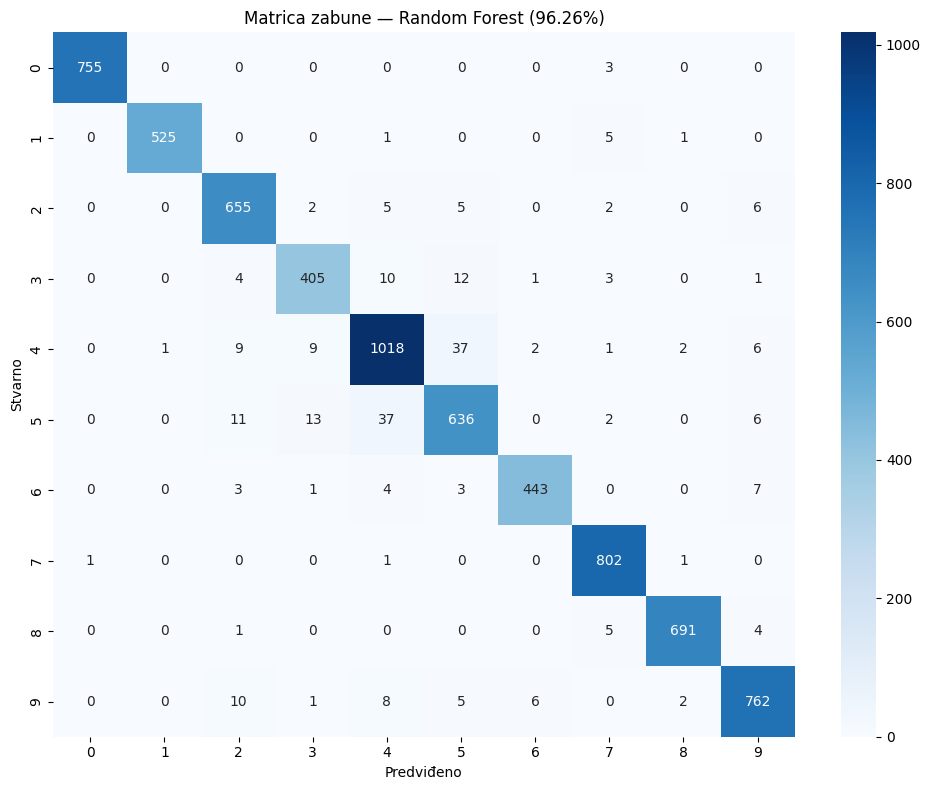

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, najbolja_predikcija, labels=najbolji_pipeline.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matrica zabune — {najbolji_naziv} ({najbolja_tacnost:.2%})")
plt.xlabel("Predviđeno")
plt.ylabel("Stvarno")
plt.tight_layout()
plt.show()
